In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, RocCurveDisplay)
from sklearn.pipeline import Pipeline

In [9]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\cleaned_loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3,640,No,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42776 entries, 0 to 42775
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42776 non-null  int64  
 1   person_gender                   42776 non-null  object 
 2   person_education                42776 non-null  object 
 3   person_income                   42776 non-null  float64
 4   person_emp_exp                  42776 non-null  int64  
 5   person_home_ownership           42776 non-null  object 
 6   loan_amnt                       42776 non-null  float64
 7   loan_intent                     42776 non-null  object 
 8   loan_int_rate                   42776 non-null  float64
 9   loan_percent_income             42776 non-null  float64
 10  cb_person_cred_hist_length      42776 non-null  int64  
 11  credit_score                    42776 non-null  int64  
 12  previous_loan_defaults_on_file  

In [11]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000
mean,27.609056,70852.732443,5.262741,9275.487586,10.993112,0.143362,5.780251,632.323523,0.229100
std,5.830140,32447.846522,5.840831,6041.753786,2.975452,0.087443,3.825896,50.403992,0.420259
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.010000,2.000000,390.000000,0.000000
25%,24.000000,46149.000000,1.000000,5000.000000,8.590000,0.080000,3.000000,601.000000,0.000000
50%,26.000000,65645.500000,4.000000,8000.000000,11.010000,0.130000,4.000000,639.000000,0.000000
75%,30.000000,90756.250000,8.000000,12000.000000,12.990000,0.190000,8.000000,669.000000,0.000000
max,78.000000,168633.000000,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [12]:
def preprocess_data(df):
    # 处理分类变量（示例）
    df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent'])
    df['person_gender'] = df['person_gender'].map({'male':0, 'female':1})
    df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No':0, 'Yes':1})
    return df

In [13]:
df_clean = preprocess_data(df)

In [14]:
# 划分数据集
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# 创建处理管道
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),  # 标准化处理
    ('lr', LogisticRegression(
        class_weight='balanced',   # 处理类别不平衡
        penalty='l2',             # 正则化类型
        C=0.1,                    # 正则化强度（C越小正则化越强）
        solver='saga',            # 支持多种正则化
        max_iter=1000,
        random_state=42
    ))
])

In [16]:
# 训练模型
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42,
                                    solver='saga'))])

In [17]:
# 预测与评估
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:, 1]

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.90      6596
           1       0.64      0.93      0.76      1960

    accuracy                           0.86      8556
   macro avg       0.81      0.89      0.83      8556
weighted avg       0.90      0.86      0.87      8556



Text(0.5, 1.0, 'ROC Curve')

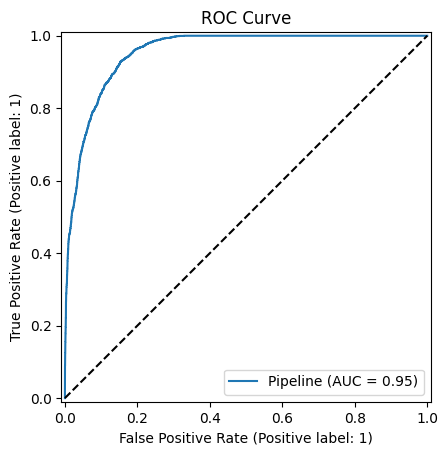

In [23]:
RocCurveDisplay.from_estimator(lr_pipe, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')